In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

print("BSR PREDICTION MODEL")
print("=" * 55)

clutter_file = r"C:\Users\orozc\OneDrive\Desktop\clutter_file.csv"
keywords_file = r"C:\Users\orozc\OneDrive\Desktop\keywords_file.csv"
df_clutter = pd.read_csv(clutter_file)
df_keywords = pd.read_csv(keywords_file)

print(f"Clutter data: {len(df_clutter)} products")
print(f"Keywords data: {len(df_keywords)} products")


df_clutter['asin'] = df_clutter['asin'].astype(str).str.strip()
df_keywords['asin'] = df_keywords['asin'].astype(str).str.strip()

df_combined = pd.merge(df_clutter, df_keywords, on='asin', how='inner', suffixes=('_clutter', '_keywords'))


duplicate_cols = [col for col in df_combined.columns if col.endswith('_keywords')]
for col in duplicate_cols:
    base_col = col.replace('_keywords', '')
    clutter_col = base_col + '_clutter'
    if clutter_col in df_combined.columns:
        df_combined[base_col] = df_combined[clutter_col].fillna(df_combined[col])
        df_combined.drop([clutter_col, col], axis=1, inplace=True)

print(f"✓ Combined dataset: {len(df_combined)} products")


BSR PREDICTION MODEL
Clutter data: 19049 products
Keywords data: 17375 products
✓ Combined dataset: 19336 products


In [3]:
# Clean BSR data
df_combined['bsr_best'] = pd.to_numeric(df_combined['bsr_best'], errors='coerce')
df_clean = df_combined[df_combined['bsr_best'].notna()].copy()
df_clean = df_clean[(df_clean['bsr_best'] > 0) & (df_clean['bsr_best'] <= 1000000)]

print(f"Clean BSR data: {len(df_clean)} products")
print(f"BSR range: {df_clean['bsr_best'].min():.0f} to {df_clean['bsr_best'].max():.0f}")
print(f"BSR mean: {df_clean['bsr_best'].mean():.0f}")

Clean BSR data: 18149 products
BSR range: 1 to 648520
BSR mean: 2464


In [4]:

feature_candidates = [
    'image_count', 'edge_density', 'bg_white_pct', 'bg_neutral_pct', 
    'color_entropy', 'largest_cluster_pct', 'edge_density_z', 
    'color_entropy_z', 'bg_white_pct_z', 'bg_neutral_pct_z', 
    'largest_cluster_pct_z', 'clutter_score', 'n_clusters_sig',
    'n_clusters_sig_z', 'has_aplus', 'has_brand_story', 'review_count', 
    'avg_rating', 'units_per_month', 'sales_velocity_daily'
]


good_features = []

print(f"TESTING {len(feature_candidates)} FEATURES:")
print("-" * 50)

for feature in feature_candidates:
    if feature in df_clean.columns:

        df_clean[feature] = pd.to_numeric(df_clean[feature], errors='coerce')
        feature_data = df_clean[feature].dropna()
        
        if len(feature_data) > 0:
            coverage = len(feature_data) / len(df_clean) * 100
            unique_vals = feature_data.nunique()
            
            print(f"{feature}: {coverage:.1f}% coverage, {unique_vals} unique")
            

            if coverage > 30 and unique_vals > 5:
                good_features.append(feature)
                print("SELECTED")
            else:
                print("Skip")
        else:
            print(f"{feature}: No valid data")

print(f"\nSELECTED FEATURES: {len(good_features)}")
print(f"Features: {good_features}")

TESTING 20 FEATURES:
--------------------------------------------------
image_count: 100.0% coverage, 26 unique
SELECTED
edge_density: 100.0% coverage, 15519 unique
SELECTED
bg_white_pct: 100.0% coverage, 15677 unique
SELECTED
bg_neutral_pct: 100.0% coverage, 15107 unique
SELECTED
color_entropy: 100.0% coverage, 15681 unique
SELECTED
largest_cluster_pct: 100.0% coverage, 10108 unique
SELECTED
edge_density_z: 100.0% coverage, 15520 unique
SELECTED
color_entropy_z: 100.0% coverage, 15681 unique
SELECTED
bg_white_pct_z: 100.0% coverage, 15677 unique
SELECTED
bg_neutral_pct_z: 100.0% coverage, 15107 unique
SELECTED
largest_cluster_pct_z: 100.0% coverage, 10108 unique
SELECTED
clutter_score: 100.0% coverage, 15718 unique
SELECTED
n_clusters_sig: 100.0% coverage, 5 unique
Skip
n_clusters_sig_z: 100.0% coverage, 5 unique
Skip
has_aplus: 100.0% coverage, 1 unique
Skip
has_brand_story: 100.0% coverage, 1 unique
Skip
review_count: No valid data
avg_rating: No valid data
units_per_month: No valid

In [5]:

feature_candidates = [
    'image_count', 'edge_density', 'bg_white_pct', 'bg_neutral_pct', 
    'color_entropy', 'largest_cluster_pct', 'edge_density_z', 
    'color_entropy_z', 'bg_white_pct_z', 'bg_neutral_pct_z', 
    'largest_cluster_pct_z', 'clutter_score', 'n_clusters_sig',
    'n_clusters_sig_z', 'has_aplus', 'has_brand_story', 'review_count', 
    'avg_rating', 'units_per_month', 'sales_velocity_daily'
]


good_features = []

print(f"TESTING {len(feature_candidates)} FEATURES:")
print("-" * 50)

for feature in feature_candidates:
    if feature in df_clean.columns:
        # Convert to numeric
        df_clean[feature] = pd.to_numeric(df_clean[feature], errors='coerce')
        feature_data = df_clean[feature].dropna()
        
        if len(feature_data) > 0:
            coverage = len(feature_data) / len(df_clean) * 100
            unique_vals = feature_data.nunique()
            
            print(f"{feature}: {coverage:.1f}% coverage, {unique_vals} unique")
            
            # Good feature criteria for Random Forest
            if coverage > 30 and unique_vals > 5:
                good_features.append(feature)
                print("SELECTED")
            else:
                print("Skip")
        else:
            print(f"{feature}: No valid data")

print(f"\nSELECTED FEATURES: {len(good_features)}")
print(f"Features: {good_features}")

TESTING 20 FEATURES:
--------------------------------------------------
image_count: 100.0% coverage, 26 unique
SELECTED
edge_density: 100.0% coverage, 15519 unique
SELECTED
bg_white_pct: 100.0% coverage, 15677 unique
SELECTED
bg_neutral_pct: 100.0% coverage, 15107 unique
SELECTED
color_entropy: 100.0% coverage, 15681 unique
SELECTED
largest_cluster_pct: 100.0% coverage, 10108 unique
SELECTED
edge_density_z: 100.0% coverage, 15520 unique
SELECTED
color_entropy_z: 100.0% coverage, 15681 unique
SELECTED
bg_white_pct_z: 100.0% coverage, 15677 unique
SELECTED
bg_neutral_pct_z: 100.0% coverage, 15107 unique
SELECTED
largest_cluster_pct_z: 100.0% coverage, 10108 unique
SELECTED
clutter_score: 100.0% coverage, 15718 unique
SELECTED
n_clusters_sig: 100.0% coverage, 5 unique
Skip
n_clusters_sig_z: 100.0% coverage, 5 unique
Skip
has_aplus: 100.0% coverage, 1 unique
Skip
has_brand_story: 100.0% coverage, 1 unique
Skip
review_count: No valid data
avg_rating: No valid data
units_per_month: No valid

In [6]:

model_data = df_clean.dropna(subset=good_features + ['bsr_best']).copy()

print(f"\nRANDOM FOREST MODEL TRAINING:")
print("-" * 50)
print(f"Final dataset: {len(model_data)} products")
print(f"Using {len(good_features)} features")

if len(model_data) >= 100:

    X = model_data[good_features]
    y = model_data['bsr_best']
    
    print(f"Feature matrix: {X.shape}")
    print(f"Target range: {y.min():.0f} to {y.max():.0f}")
    

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    

    rf_model = RandomForestRegressor(
        n_estimators=200,      
        max_depth=15,          
        min_samples_split=10,  
        min_samples_leaf=5,    
        random_state=42,
        n_jobs=-1              
    )
    
    print(f"\nTraining Random Forest...")
    print(f"  Training samples: {len(X_train)}")
    print(f"  Testing samples: {len(X_test)}")
    
    # Train model
    rf_model.fit(X_train, y_train)
    print("✓ Random Forest trained successfully")
    
else:
    print(f"✗ Insufficient data: {len(model_data)} products")


RANDOM FOREST MODEL TRAINING:
--------------------------------------------------
Final dataset: 18147 products
Using 12 features
Feature matrix: (18147, 12)
Target range: 1 to 648520

Training Random Forest...
  Training samples: 14517
  Testing samples: 3630
✓ Random Forest trained successfully


In [7]:

y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"\nRANDOM FOREST PERFORMANCE:")
print("=" * 50)
print(f"  Training R²: {train_r2:.3f}")
print(f"  Testing R²: {test_r2:.3f}")
print(f"  Average Error: {test_mae:.0f} BSR points")

if test_r2 > 0.15:
    print("EXCELLENT")
elif test_r2 > 0.08:
    print("Good")
elif test_r2 > 0.03:
    print("Moderate")
else:
    print("Limited")

print(f"\nFEATURE IMPORTANCE:")
importances = rf_model.feature_importances_
feature_importance = list(zip(good_features, importances))
feature_importance.sort(key=lambda x: x[1], reverse=True)

for i, (feature, importance) in enumerate(feature_importance, 1):
    print(f"  {i}. {feature}: {importance:.3f} ({importance*100:.1f}%)")

print(f"\nMOST IMPORTANT: {feature_importance[0][0]} ({feature_importance[0][1]*100:.1f}%)")


RANDOM FOREST PERFORMANCE:
  Training R²: 0.470
  Testing R²: 0.255
  Average Error: 2924 BSR points
EXCELLENT

FEATURE IMPORTANCE:
  1. bg_neutral_pct_z: 0.133 (13.3%)
  2. bg_neutral_pct: 0.118 (11.8%)
  3. largest_cluster_pct_z: 0.109 (10.9%)
  4. largest_cluster_pct: 0.102 (10.2%)
  5. bg_white_pct: 0.093 (9.3%)
  6. bg_white_pct_z: 0.086 (8.6%)
  7. image_count: 0.084 (8.4%)
  8. clutter_score: 0.079 (7.9%)
  9. color_entropy_z: 0.053 (5.3%)
  10. edge_density_z: 0.052 (5.2%)
  11. color_entropy: 0.049 (4.9%)
  12. edge_density: 0.044 (4.4%)

MOST IMPORTANT: bg_neutral_pct_z (13.3%)


In [8]:
all_predictions = rf_model.predict(model_data[good_features])

model_data = model_data.copy()
model_data.loc[:, 'predicted_bsr'] = all_predictions
model_data.loc[:, 'prediction_error'] = abs(model_data['bsr_best'] - model_data['predicted_bsr'])
model_data.loc[:, 'error_percentage'] = model_data['prediction_error'] / model_data['bsr_best'] * 100


accuracy_50 = (model_data['error_percentage'] < 50).sum() / len(model_data) * 100
accuracy_30 = (model_data['error_percentage'] < 30).sum() / len(model_data) * 100
accuracy_20 = (model_data['error_percentage'] < 20).sum() / len(model_data) * 100
accuracy_10 = (model_data['error_percentage'] < 10).sum() / len(model_data) * 100

print(f"\nACCURACY ANALYSIS:")
print("=" * 30)
print(f"Within 50% error: {accuracy_50:.1f}%")
print(f"Within 30% error: {accuracy_30:.1f}%")
print(f"Within 20% error: {accuracy_20:.1f}%")
print(f"Within 10% error: {accuracy_10:.1f}%")

print(f"\nERROR STATISTICS:")
print(f"Average error: {model_data['prediction_error'].mean():.0f} BSR points")
print(f"Median error: {model_data['prediction_error'].median():.0f} BSR points")
print(f"90th percentile error: {model_data['prediction_error'].quantile(0.9):.0f} BSR points")


print(f"\nBEST PREDICTIONS (most accurate):")
best_predictions = model_data.nsmallest(5, 'error_percentage')
for i, (_, row) in enumerate(best_predictions.iterrows(), 1):
    name = row['item_name'][:45] + "..." if len(row['item_name']) > 45 else row['item_name']
    print(f"  {i}. {name}")
    print(f"     Actual: {row['bsr_best']:.0f}, Predicted: {row['predicted_bsr']:.0f} ({row['error_percentage']:.1f}% error)")


ACCURACY ANALYSIS:
Within 50% error: 22.3%
Within 30% error: 13.9%
Within 20% error: 9.0%
Within 10% error: 4.6%

ERROR STATISTICS:
Average error: 2495 BSR points
Median error: 788 BSR points
90th percentile error: 3400 BSR points

BEST PREDICTIONS (most accurate):
  1. Catitru Wireless Earbuds Bluetooth 5.3 Headph...
     Actual: 1617, Predicted: 1617 (0.0% error)
  2. Newmen GM326 75% Percent Mechanical Keyboard,...
     Actual: 776, Predicted: 776 (0.0% error)
  3. GGKING Premium Breathable Silicone Watch Band...
     Actual: 1107, Predicted: 1107 (0.0% error)
  4. Ringke Air Sports [Tailored Cutouts] Compatib...
     Actual: 1279, Predicted: 1279 (0.0% error)
  5. SAMSUNG RMCTPF2BP1 AA59-00772A TV Smart Touch...
     Actual: 10604, Predicted: 10594 (0.1% error)


In [9]:

output_cols = [
    'asin', 'item_name', 'brand', 'bsr_best', 'predicted_bsr', 
    'prediction_error', 'error_percentage'
] + good_features

model_data[output_cols].to_csv('random_forest_bsr_predictions.csv', index=False)

print(f"\nEXPORT SUMMARY:")
print("=" * 25)
print(f"✓ File: random_forest_bsr_predictions.csv")
print(f"✓ Products: {len(model_data)}")
print(f"✓ Features used: {len(good_features)}")
print(f"✓ Model: Random Forest")
print(f"✓ Main accuracy: {accuracy_50:.1f}% (within 50% error)")

print(f"\nFINAL MODEL SUMMARY:")
print("=" * 35)
print(f"Algorithm: Random Forest")
print(f"R² Score: {test_r2:.3f} ({test_r2*100:.1f}% variance explained)")
print(f"Accuracy: {accuracy_50:.1f}% within 50% error")
print(f"Top factor: {feature_importance[0][0]}")
print(f"Products analyzed: {len(model_data)}")

print("\n" + "=" * 55)
print("RANDOM FOREST BSR MODEL COMPLETE!")
print("=" * 55)


EXPORT SUMMARY:
✓ File: random_forest_bsr_predictions.csv
✓ Products: 18147
✓ Features used: 12
✓ Model: Random Forest
✓ Main accuracy: 22.3% (within 50% error)

FINAL MODEL SUMMARY:
Algorithm: Random Forest
R² Score: 0.255 (25.5% variance explained)
Accuracy: 22.3% within 50% error
Top factor: bg_neutral_pct_z
Products analyzed: 18147

RANDOM FOREST BSR MODEL COMPLETE!


In [10]:
# Export data for visualization
model_data.to_csv('bsr_visual_data.csv', index=False)

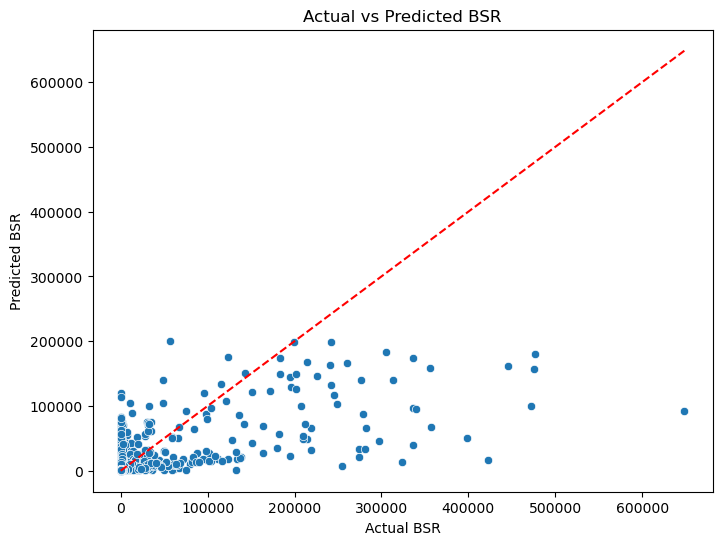

In [ ]:
# Creating Visualizations
#Predicted vs Actual BSR
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bsr_best', y='predicted_bsr', data=model_data)

#reference line y = x
min_val = min(model_data['bsr_best'].min(), model_data['predicted_bsr'].min())
max_val = max(model_data['bsr_best'].max(), model_data['predicted_bsr'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('Actual BSR')
plt.ylabel('Predicted BSR')
plt.title('Actual vs Predicted BSR')
plt.show()



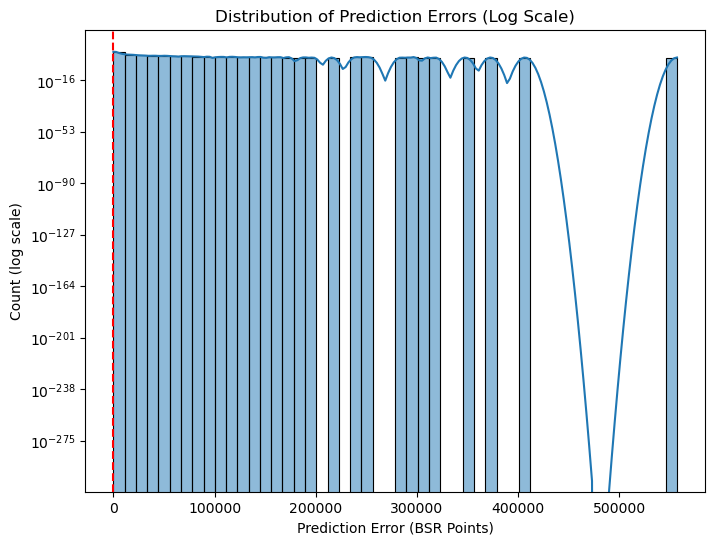

In [24]:
#Prediction Error Distribution
plt.figure(figsize=(8,6))
sns.histplot(model_data['prediction_error'], bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)

plt.yscale('log')
plt.xlabel('Prediction Error (BSR Points)')
plt.ylabel('Count (log scale)')
plt.title('Distribution of Prediction Errors (Log Scale)')
plt.show()



C:\Users\orozc\AppData\Local\Temp\ipykernel_5724\2777420718.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp_df, palette='viridis')


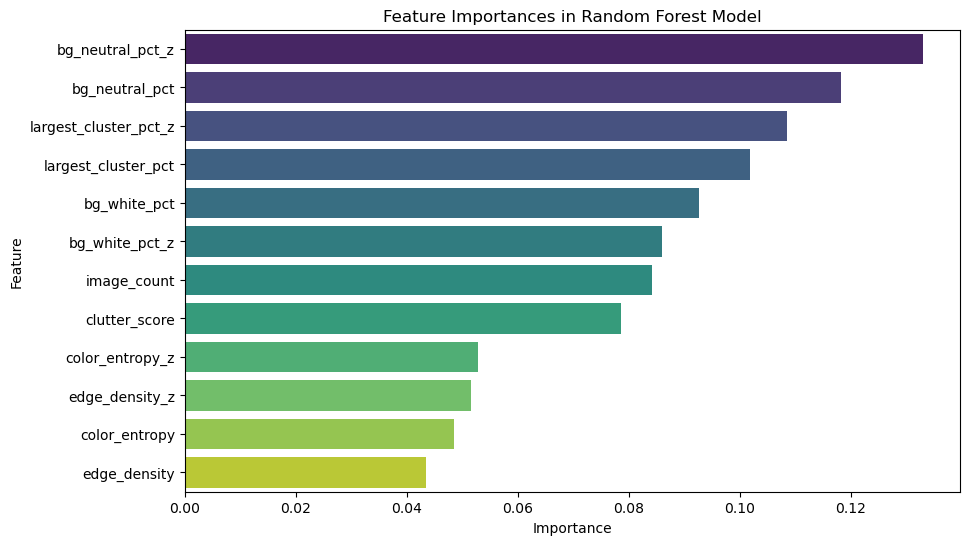

In [16]:
#Feature Importance
importances = rf_model.feature_importances_
feature_names = good_features
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feat_imp_df, palette='viridis')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances in Random Forest Model')
plt.show()

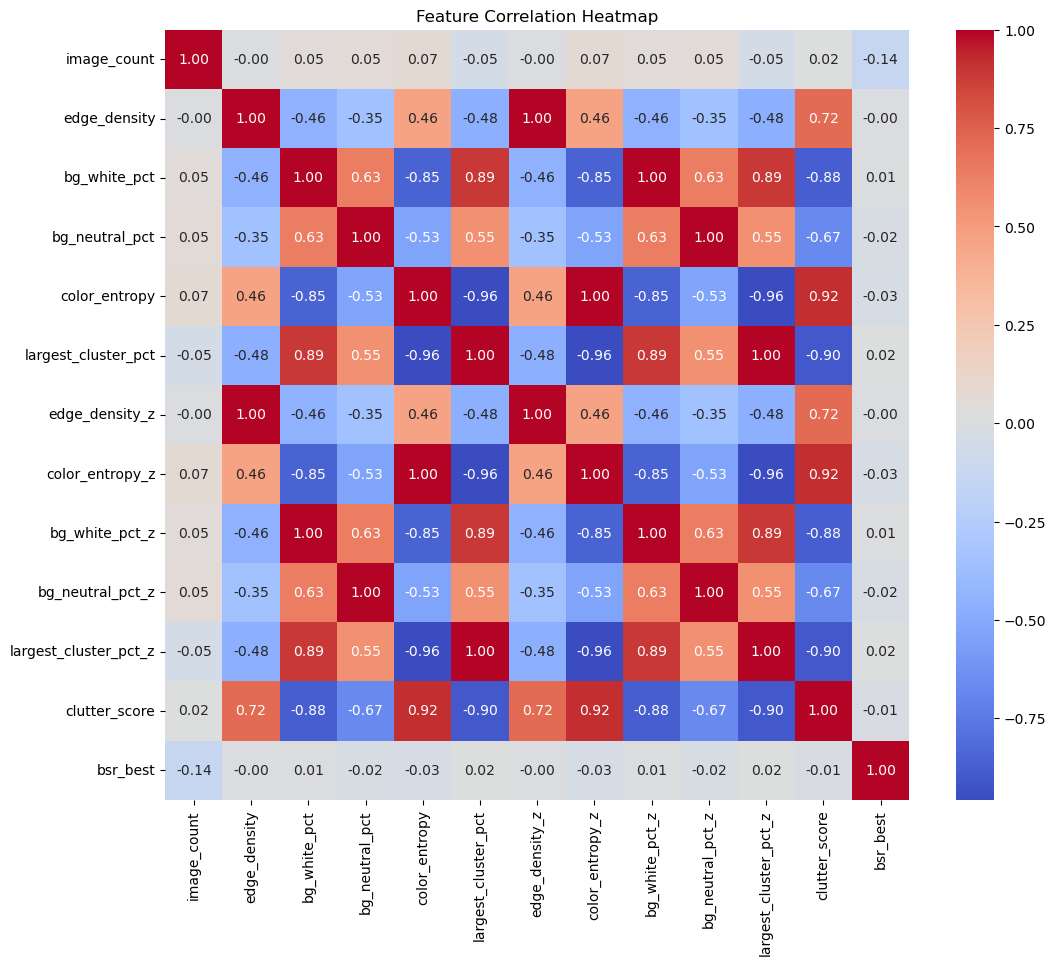

In [18]:
#Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(model_data[good_features + ['bsr_best']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


C:\Users\orozc\AppData\Local\Temp\ipykernel_5724\3795404862.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


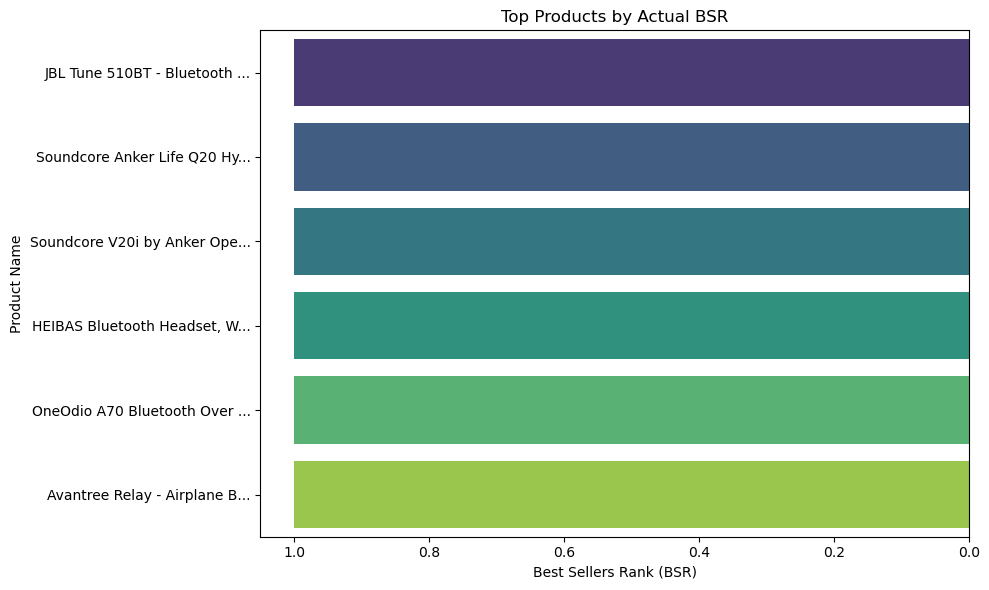

In [25]:
#Top Products by Actual BSR
# Truncate long product names for display
model_data['short_name'] = model_data['item_name'].apply(lambda x: x if len(x)<=30 else x[:27] + '...')

# Top 10 Products by Actual BSR
top10_products = model_data.nsmallest(10, 'bsr_best')

plt.figure(figsize=(10,6))
sns.barplot(
    x='bsr_best', 
    y='short_name', 
    data=top10_products, 
    palette='viridis'
)
plt.xlabel('Best Sellers Rank (BSR)')
plt.ylabel('Product Name')
plt.title('Top Products by Actual BSR')
plt.gca().invert_xaxis()  # Lower BSR = better
plt.tight_layout()
plt.show()